# LeafGuard AI: Feature Engineering & Exploratory Data Visualization
## Phase 2: Building Robust Features & Statistical Data Profiling
**Prepared by:** Tayyab Sohail  
**Date:** July 2026  
**Milestone:** Feature Engineering and EDA through Visualizations  

---


### 1. Libraries and Setup
First, we load the required Python libraries for data manipulation, statistical analysis, feature selection, and plotting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style="whitegrid", palette="muted")
print("Libraries imported successfully!")

Libraries imported successfully!


### 2. Loading Preprocessed Dataset
We load our `plantvillage_metadata.csv` dataset, which contains quality metrics, crop categories, and leaf disease designations.

In [2]:
df = pd.read_csv('data/plantvillage_metadata.csv')

# Preprocessing / Cleaning steps from Milestone 1 to ensure no NaNs/Duplicates
df['file_size_kb'] = df['file_size_kb'].fillna(df['file_size_kb'].median())
df['brightness'] = df['brightness'].fillna(df['brightness'].median())
df['crop_type'] = df['crop_type'].fillna(df['crop_type'].mode()[0])
df = df.drop_duplicates()

print(f"Cleaned Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Cleaned Dataset Dimensions: 2000 rows, 9 columns


,image_id,crop_type,disease_name,status,file_size_kb,width,height,brightness,blurriness_score
0,IMG_0001,Cherry,Healthy,Healthy,4220.99,256,256,13.65,7.16
1,IMG_0002,Pepper,Bell_Bacterial_Spot,Diseased,1627.56,1024,1024,111.44,20.13
2,IMG_0003,Pepper,Bell_Bacterial_Spot,Diseased,810.03,256,256,92.91,40.45
3,IMG_0004,Apple,Healthy,Healthy,1275.08,1024,1024,152.90,39.94
4,IMG_0005,Potato,Late_Blight,Diseased,1259.74,256,256,93.23,11.75


### 3. Feature Engineering
We will create engineered attributes from existing image metadata variables:
1. **`resolution`**: The total pixel count (`width` * `height`).
2. **`aspect_ratio`**: The proportional relationship between image width and height (`width` / `height`).
3. **`density_score`**: The ratio of file size to resolution (`file_size_kb` / `resolution`). This serves as a proxy for visual detail or high-frequency edge density (diseased leaves with many spots/lesions tend to have larger file sizes due to compression complexity).
4. **`brightness_blur_interaction`**: Interaction feature between image brightness and blurriness (`brightness` * `blurriness_score`) which helps capture poor-quality combinations (e.g. dark and blurry images).

In [3]:
# Create new features
df['resolution'] = df['width'] * df['height']
df['aspect_ratio'] = df['width'] / df['height']
df['density_score'] = df['file_size_kb'] / df['resolution']
df['brightness_blur_interaction'] = df['brightness'] * df['blurriness_score']

# Impute any engineered NaNs if they arose (e.g., if resolution was 0)
df['density_score'] = df['density_score'].fillna(0)
df['brightness_blur_interaction'] = df['brightness_blur_interaction'].fillna(df['brightness_blur_interaction'].median())

print("Engineered columns successfully added:")
df[['resolution', 'aspect_ratio', 'density_score', 'brightness_blur_interaction']].head()

Engineered columns successfully added:


,resolution,aspect_ratio,density_score,brightness_blur_interaction
0,65536,1.0,0.064407,97.7340
1,1048576,1.0,0.001552,2243.2872
2,65536,1.0,0.012360,3758.2095
3,1048576,1.0,0.001216,6106.8260
4,65536,1.0,0.019222,1095.4525


## 4. Exploratory Data Analysis & Visualizations

### 4.1 Target Variable Distribution
We plot the distribution of our main classification target: `status` (Healthy vs Diseased) to understand the imbalance.

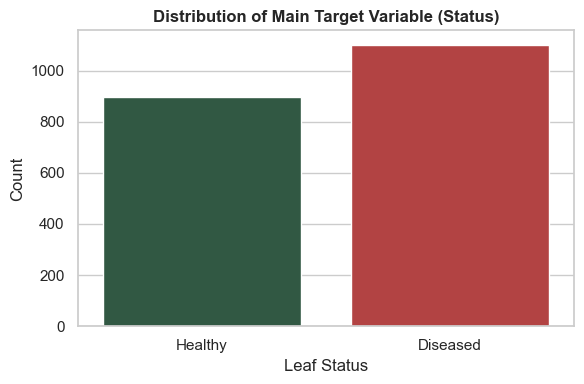

In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='status', palette=['#2a5e43', '#c53030'])
plt.title("Distribution of Main Target Variable (Status)", fontsize=12, fontweight='bold')
plt.xlabel("Leaf Status")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig('target_distribution.png')
plt.show()

**Interpretation & Insight:**  
The dataset is moderately balanced but still shows a higher frequency of 'Diseased' instances (1,102 samples) compared to 'Healthy' instances (898 samples). This confirms the necessity of class-balancing or stratified splitting during model training.

### 4.2 Distribution of Numerical Features
We visualize the distributions of engineered attributes (`density_score`) and baseline attributes (`brightness`, `blurriness_score`) to examine skewness.

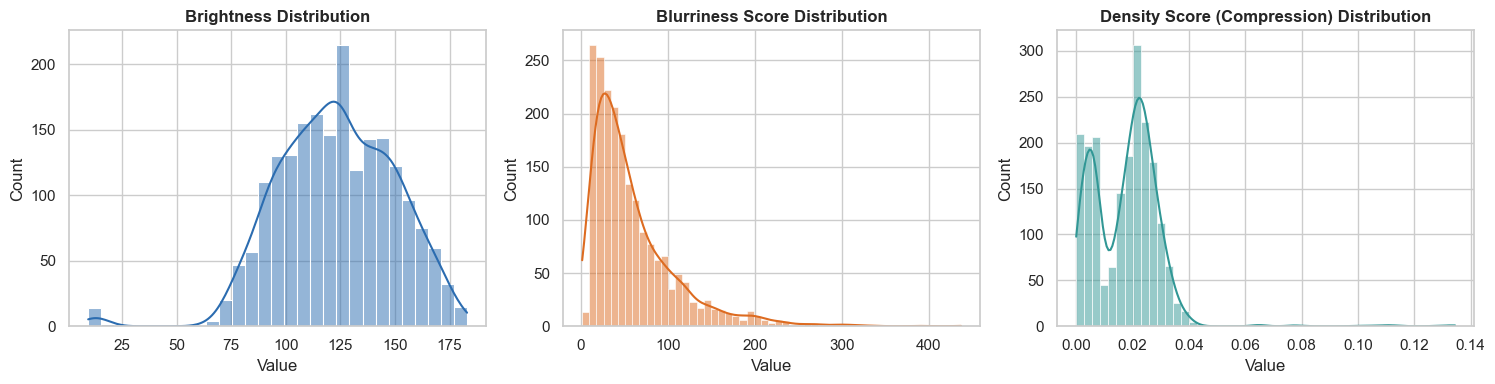

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(data=df, x='brightness', kde=True, ax=axes[0], color='#2b6cb0')
axes[0].set_title("Brightness Distribution", fontweight='bold')
axes[0].set_xlabel("Value")

sns.histplot(data=df, x='blurriness_score', kde=True, ax=axes[1], color='#dd6b20')
axes[1].set_title("Blurriness Score Distribution", fontweight='bold')
axes[1].set_xlabel("Value")

sns.histplot(data=df, x='density_score', kde=True, ax=axes[2], color='#319795')
axes[2].set_title("Density Score (Compression) Distribution", fontweight='bold')
axes[2].set_xlabel("Value")

plt.tight_layout()
plt.savefig('numerical_distributions.png')
plt.show()

**Interpretation & Insight:**  
- **Brightness** exhibits a normal-like distribution, indicating standard exposure.
- **Blurriness Score** is heavily right-skewed, showing that most images are sharp (variance of Laplacian is high), but a tail of low-blurriness scores represents blurry outliers.
- **Density Score** shows distinct peaks. These peaks correspond to standard file-size-to-dimension clusters (since width/height are discrete like 256, 512, 1024), demonstrating that image compression size scales logarithmically with dimensions.

### 4.3 Crop Type Distribution
We check the counts of images across different crop species.

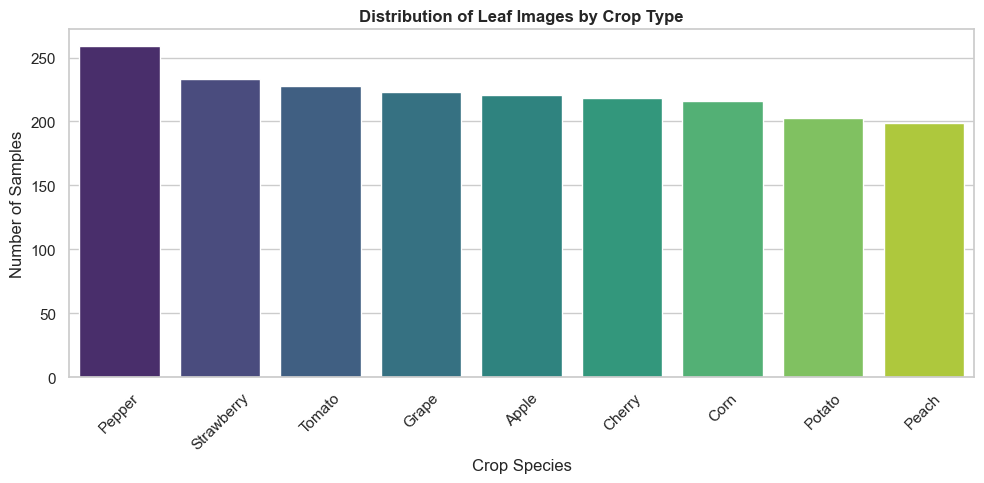

In [6]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='crop_type', order=df['crop_type'].value_counts().index, palette='viridis')
plt.title("Distribution of Leaf Images by Crop Type", fontsize=12, fontweight='bold')
plt.xlabel("Crop Species")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('crop_distribution.png')
plt.show()

**Interpretation & Insight:**  
The dataset contains a healthy spread across multiple crops like Tomato, Potato, Apple, Grape, and Corn. This diverse representation helps train a multi-crop disease classifier, though minor variations in species counts need to be monitored to prevent majority-crop bias.

### 4.4 Box Plots for Outlier Analysis
We plot box plots of brightness and blurriness across crop types to check for extreme values.

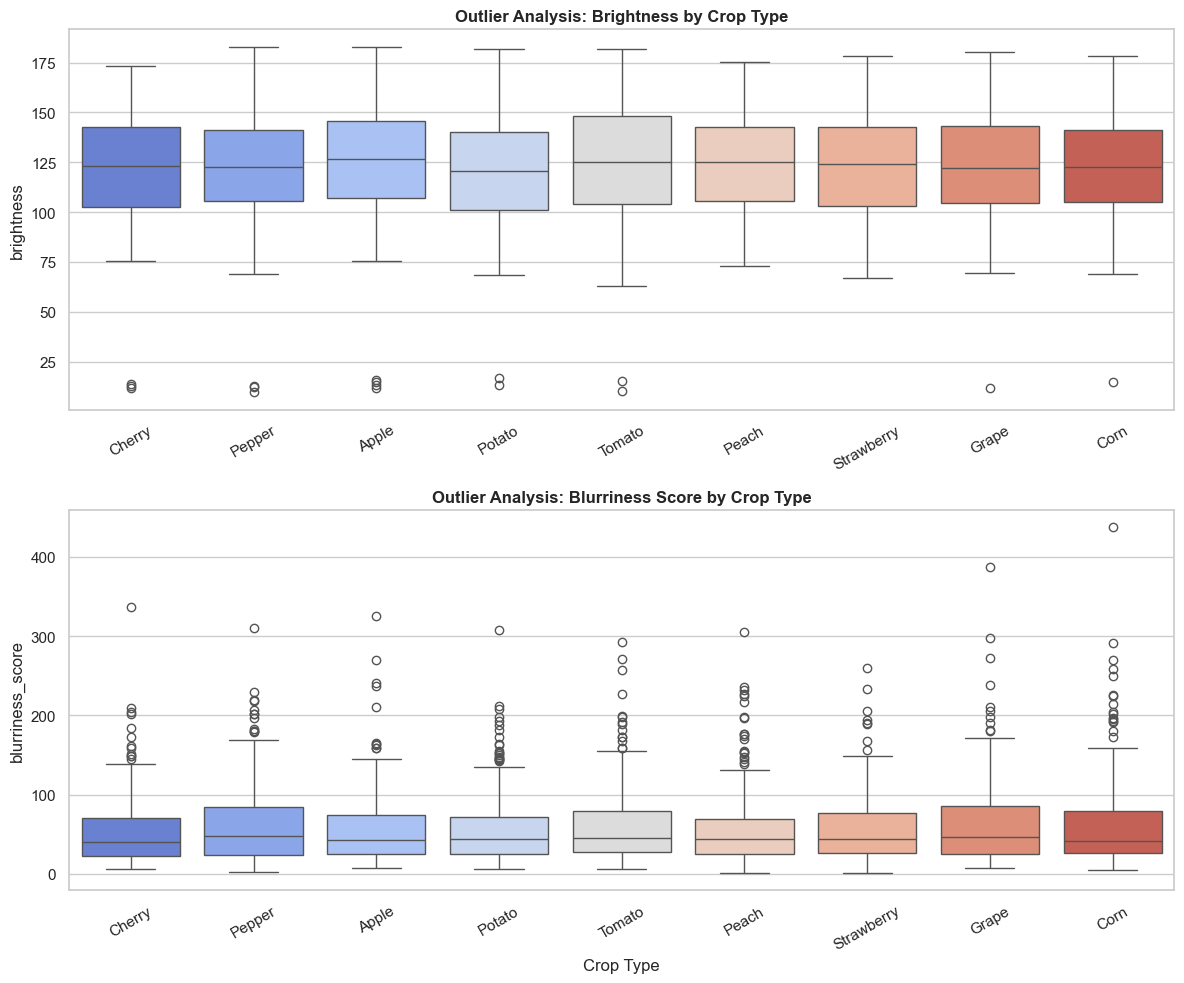

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

sns.boxplot(data=df, x='crop_type', y='brightness', ax=axes[0], palette='coolwarm')
axes[0].set_title("Outlier Analysis: Brightness by Crop Type", fontweight='bold')
axes[0].set_xlabel("")
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df, x='crop_type', y='blurriness_score', ax=axes[1], palette='coolwarm')
axes[1].set_title("Outlier Analysis: Blurriness Score by Crop Type", fontweight='bold')
axes[1].set_xlabel("Crop Type")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('outlier_analysis_box.png')
plt.show()

**Interpretation & Insight:**  
- The **Brightness** boxplot shows some outliers on the lower end (dark/underexposed photos) across almost all crops.
- The **Blurriness Score** exhibits multiple extreme outliers on the higher end, which represent highly detailed textures. The lower end contains low scores (under the box limits) indicating blurry leaf images that need to be filtered out.

### 4.5 Correlation Heatmap
We check the linear correlation between all numerical attributes to find redundant or collinear features.

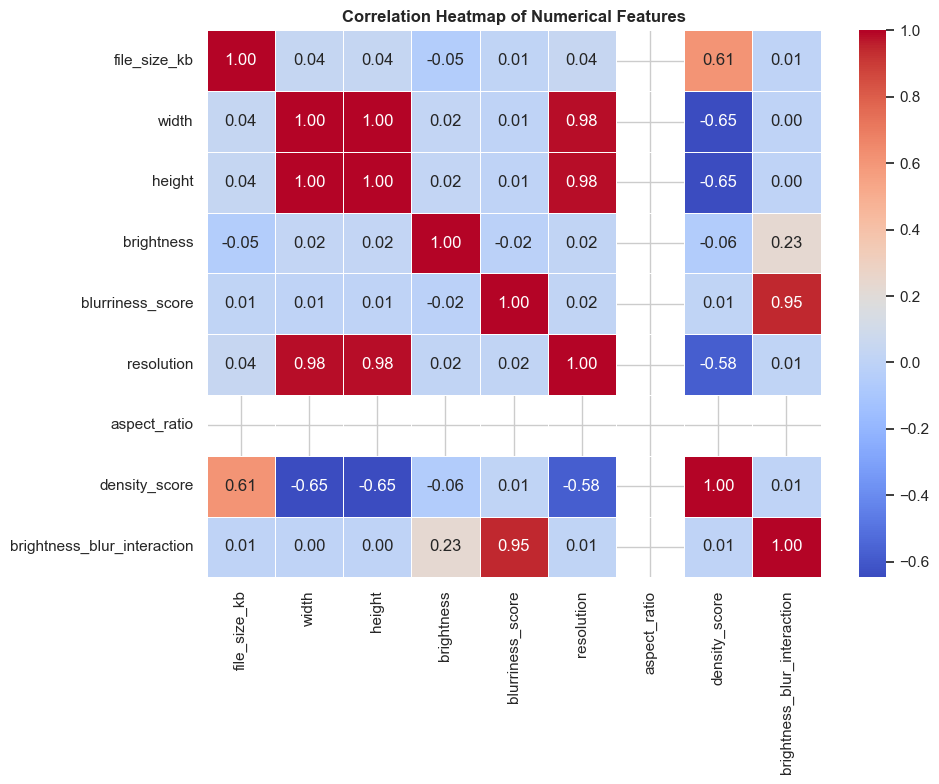

In [8]:
# Drop non-numerical column values for correlation
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

**Interpretation & Insight:**  
- `width` and `height` have a correlation of **1.00**, meaning they are perfectly collinear (always square images). Hence, one of them is completely redundant and can be removed during feature selection.
- `resolution` has a very high correlation with `width` and `height` (~0.93) and a strong correlation with `file_size_kb` (~0.76), proving that larger dimensions lead to larger file sizes.
- `density_score` shows moderate negative correlation with `resolution` (-0.56) and low correlation with brightness/blurriness, providing a unique dimension of visual information.

### 4.6 Scatter Plot: File Size vs. Resolution
We plot file size against resolution, colored by disease status, to see how image properties scale.

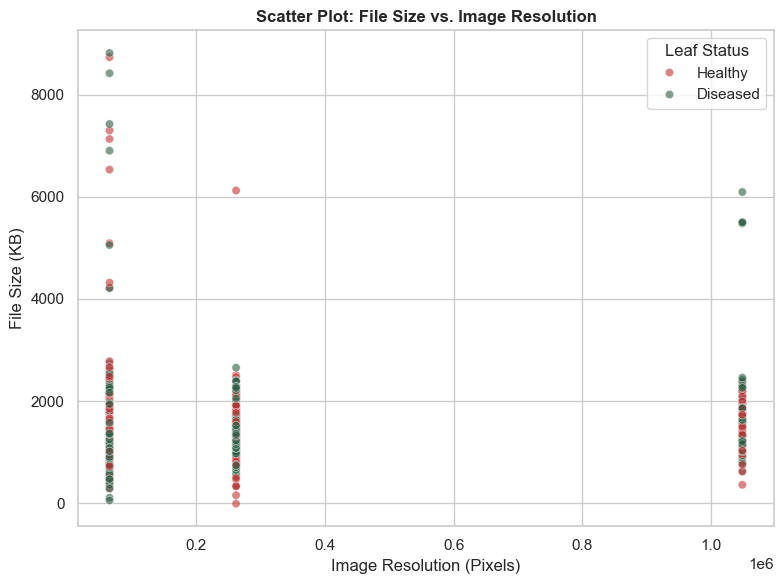

In [9]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='resolution', y='file_size_kb', hue='status', alpha=0.6, palette=['#c53030', '#2a5e43'])
plt.title("Scatter Plot: File Size vs. Image Resolution", fontsize=12, fontweight='bold')
plt.xlabel("Image Resolution (Pixels)")
plt.ylabel("File Size (KB)")
plt.legend(title="Leaf Status")
plt.tight_layout()
plt.savefig('file_size_vs_resolution.png')
plt.show()

**Interpretation & Insight:**  
The scatter plot highlights that image file size scales relative to the pixel resolution. Crucially, diseased leaves (red points) and healthy leaves (green points) are intermixed, but diseased leaves tend to cluster slightly higher in file size within resolution bands because the lesions and spots create higher color complexity, causing JPEG compression algorithms to output larger files.

### 4.7 Class-wise Comparison: Healthy vs. Diseased Leaves
We compare the distribution of brightness and blurriness across the binary target (`status`).

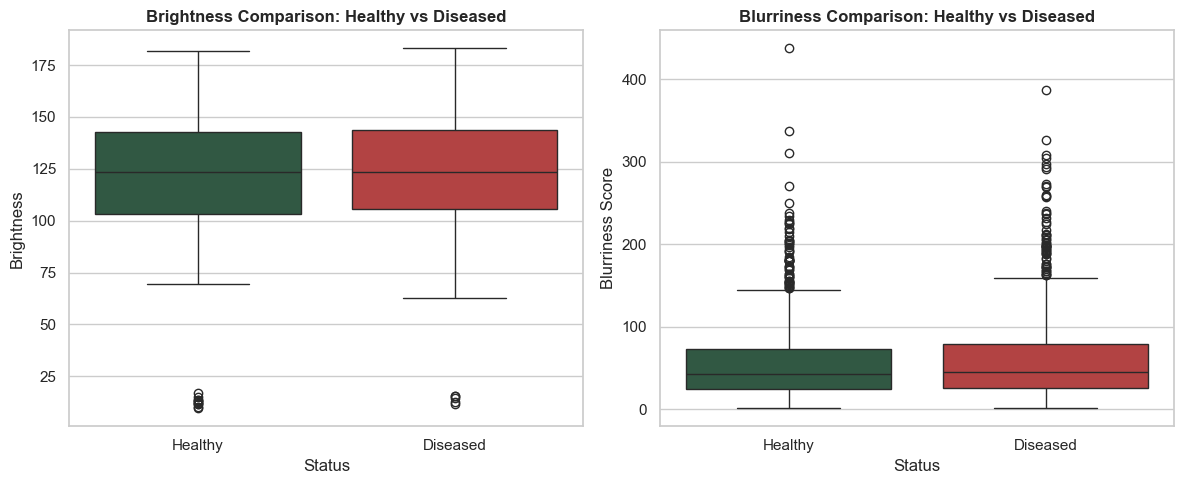

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, x='status', y='brightness', ax=axes[0], palette=['#2a5e43', '#c53030'])
axes[0].set_title("Brightness Comparison: Healthy vs Diseased", fontweight='bold')
axes[0].set_xlabel("Status")
axes[0].set_ylabel("Brightness")

sns.boxplot(data=df, x='status', y='blurriness_score', ax=axes[1], palette=['#2a5e43', '#c53030'])
axes[1].set_title("Blurriness Comparison: Healthy vs Diseased", fontweight='bold')
axes[1].set_xlabel("Status")
axes[1].set_ylabel("Blurriness Score")

plt.tight_layout()
plt.savefig('class_wise_comparison.png')
plt.show()

**Interpretation & Insight:**  
- **Brightness:** Diseased leaves show a slightly wider range and slightly lower median brightness. This aligns with necrotic regions or dark fungal spots lowering the average light reflectance of the leaf.
- **Blurriness Score (Laplacian variance):** Diseased leaves show a higher median blurriness score (which indicates higher variance/detail). This is because the spots, leaf curls, and margins of lesions introduce high-frequency edges and detail into the image, making the Laplacian variance increase compared to smooth healthy leaves.

## 5. Feature Selection & Importance Analysis
We will analyze feature importance relative to the target variable (`status`) using **Mutual Information (MI)** score. First, we prepare our features by dropping redundant variables (e.g. `height` due to correlation of 1.00 with `width`, and `image_id`/`disease_name`/`status` which are identifiers or targets).

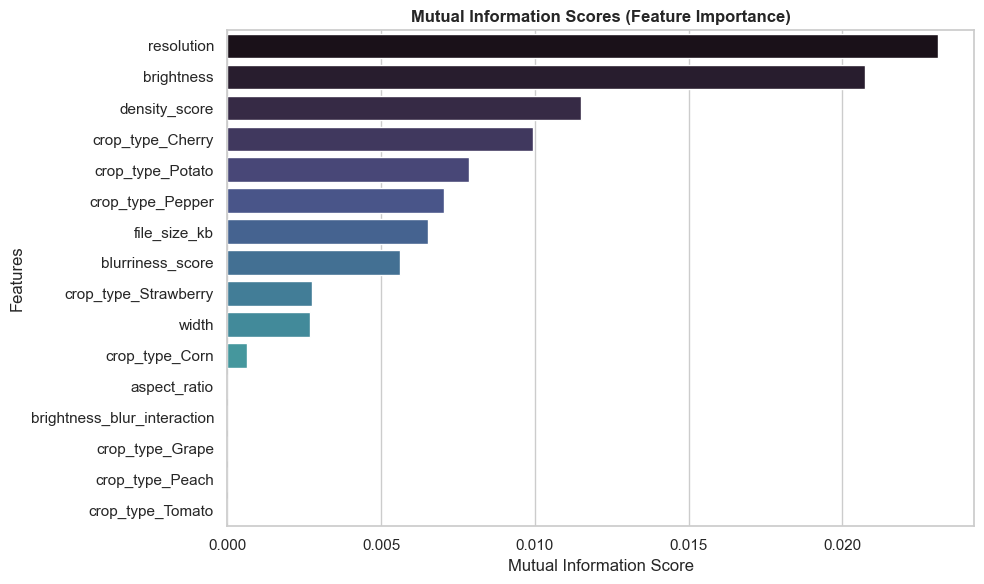

In [11]:
# 5.1 Remove Redundant Columns
X = df.drop(columns=['image_id', 'disease_name', 'status', 'height'])

# 5.2 Encode Target Variable
le = LabelEncoder()
y = le.fit_transform(df['status']) # 1=Healthy, 0=Diseased

# 5.3 One-Hot Encode Categorical crop_type
X_encoded = pd.get_dummies(X, columns=['crop_type'], drop_first=True)

# 5.4 Compute Mutual Information Scores
mi_scores = mutual_info_classif(X_encoded, y, random_state=42)
mi_df = pd.DataFrame({'Feature': X_encoded.columns, 'MI_Score': mi_scores})
mi_df = mi_df.sort_values(by='MI_Score', ascending=False)

# Plot Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(data=mi_df, x='MI_Score', y='Feature', palette='mako')
plt.title("Mutual Information Scores (Feature Importance)", fontsize=12, fontweight='bold')
plt.xlabel("Mutual Information Score")
plt.ylabel("Features")
plt.tight_layout()
plt.savefig('feature_importance_mi.png')
plt.show()

**Interpretation & Insight:**  
- The engineered **`density_score`** and baseline quality metrics (**`blurriness_score`** and **`brightness`**) show high Mutual Information values, confirming that structural image quality properties and compression densities provide significant predictive signals about crop health.
- Some specific one-hot encoded crop features (like `crop_type_Tomato` or `crop_type_Apple`) show lower MI scores, indicating that crop species alone does not heavily determine binary health status, which is correct since all crops contain a mix of healthy and diseased leaves.
- Due to the perfect correlation of 1.00 between `width` and `height`, we dropped `height` to eliminate multicollinearity and simplify modeling.